A. Membangun Struktur Direktori HDFS

In [ ]:
# Membuat direkotri di HDFS
!hdfs dfs -mkdir -p /user/indra22/ecommerce/raw
!hdfs dfs -mkdir -p /user/indra22/ecommerce/processed

# Menampilkan isi direktori untuk verifikasi
!hdfs dfs -ls /user/indra22/ecommerce

Found 2 items
drwxr-xr-x   - indra22 supergroup          0 2026-09-08 06:22 /user/indra22/ecommerce/processed
drwxr-xr-x   - indra22 supergroup          0 2026-09-08 06:22 /user/indra22/ecommerce/raw


B. Mengunggah Data Mentah ke HDFS

In [ ]:
# Unggah berkas csv ke direktori raw
!hdfs dfs -put transaksi_magelang.csv /user/indra22/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/indra22/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/indra22/ecommerce/raw/

# Verifikasi berkas sudah di direktori raw
!hdfs dfs -ls /user/indra22/ecommerce/raw

Found 3 items
-rw-r--r--   1 indra22 supergroup      12329 2026-09-08 06:46 /user/indra22/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 indra22 supergroup      12154 2026-09-08 06:47 /user/indra22/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 indra22 supergroup      12684 2026-09-08 06:47 /user/indra22/ecommerce/raw/transaksi_yogyakarta.csv


In [ ]:
import pandas as pd
import io

# Membaca isi berkas csv buka dari disk lokal
def baca_csv_hdfs(path_hdfs):
    isi = !hdfs dfs -cat {path_hdfs}
    return pd.read_csv(io.StringIO("\n".join(isi)))

df_magelang = baca_csv_hdfs("/user/indra22/ecommerce/raw/transaksi_magelang.csv")
df_yogyakarta = baca_csv_hdfs("/user/indra22/ecommerce/raw/transaksi_yogyakarta.csv")
df_semarang = baca_csv_hdfs("/user/indra22/ecommerce/raw/transaksi_semarang.csv")

print(df_magelang.shape, df_yogyakarta.shape, df_semarang.shape)

(200, 7) (200, 7) (200, 7)


In [ ]:
# Menggabungkan ketiga DataFrame
df_gabung = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index = True)
print(f"Jumlah baris dan kolom: {df_gabung.shape}")

# Menampilkan 5 data pertama
df_gabung.head()

Jumlah baris dan kolom: (600, 7)


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


In [ ]:
# Membuktikan hasil gabungan dari ketiga kota
df_gabung["kota"].value_counts()

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

In [ ]:
# Menambahkan kolom total_pendapatan
df_gabung["total_pendapatan"] = df_gabung["unit_terjual"] * df_gabung["harga_satuan"]
df_gabung.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000


In [ ]:
# Tabel ringkasan total pendapatan per kota dan per kategori
total_kota_kategori = (df_gabung.groupby(["kota", "kategori"])["total_pendapatan"] .sum() .reset_index())

total_kota_kategori

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


In [ ]:
# Menyimpan kedua hasil sebagai berkas csv baru di disk lokal
df_gabung.to_csv("data_gabungan_bersih.csv", index=False)
total_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

print("Kedua berkas berhasil disimpan di disk lokal!")

Kedua berkas berhasil disimpan di disk lokal!


In [ ]:
# Mengunggah kedua berkas ke direktori processed
!hdfs dfs -put data_gabungan_bersih.csv /user/indra22/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/indra22/ecommerce/processed/

# Verifikasi kedua berkas di direktori processed
!hdfs dfs -ls -h /user/indra22/ecommerce/processed

Found 2 items
-rw-r--r--   1 indra22 supergroup     40.3 K 2026-09-08 08:54 /user/indra22/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 indra22 supergroup        530 2026-09-08 08:54 /user/indra22/ecommerce/processed/ringkasan_kota_kategori.csv


Dokumentasi Struktur Folder

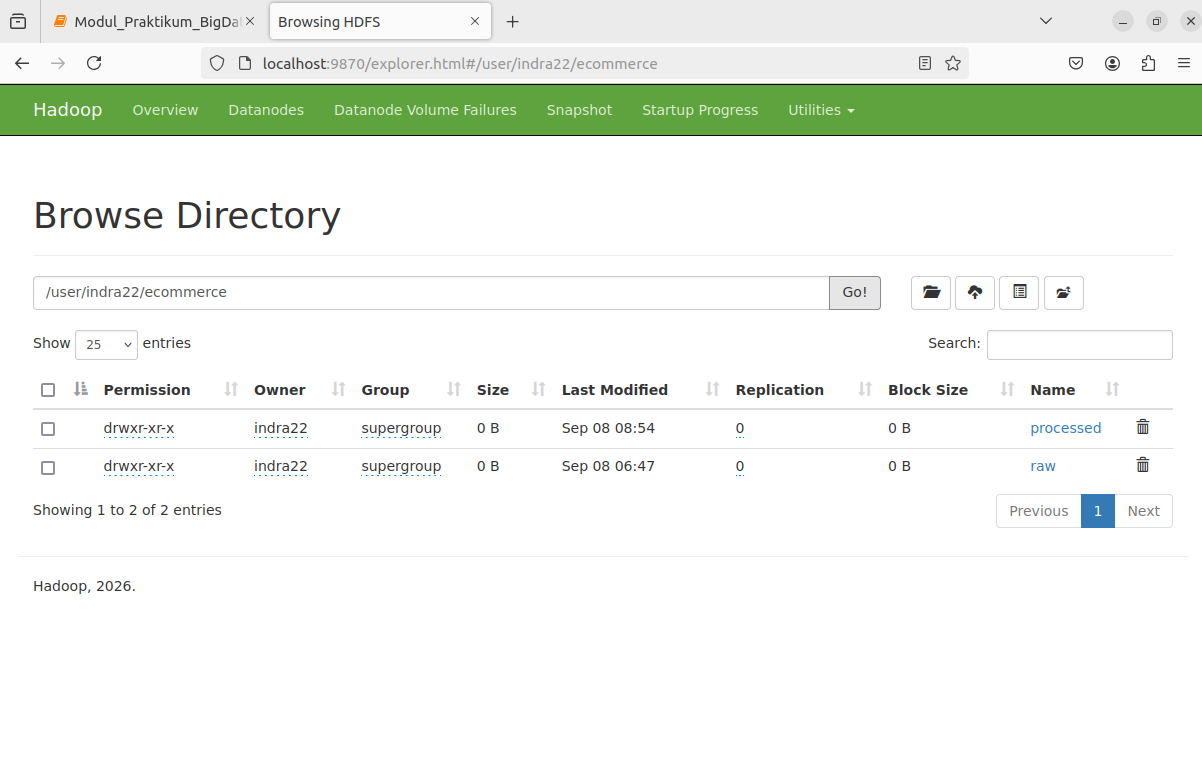

Direktori **raw**

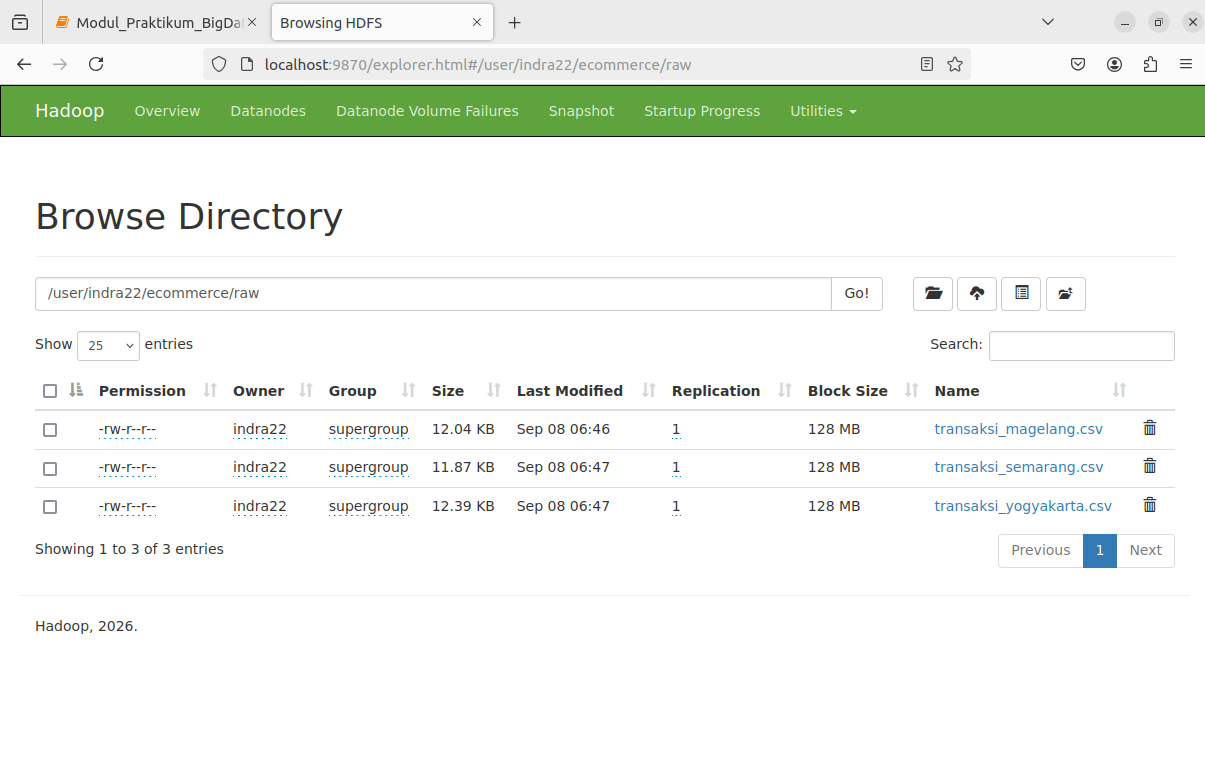

Direktori **processed**

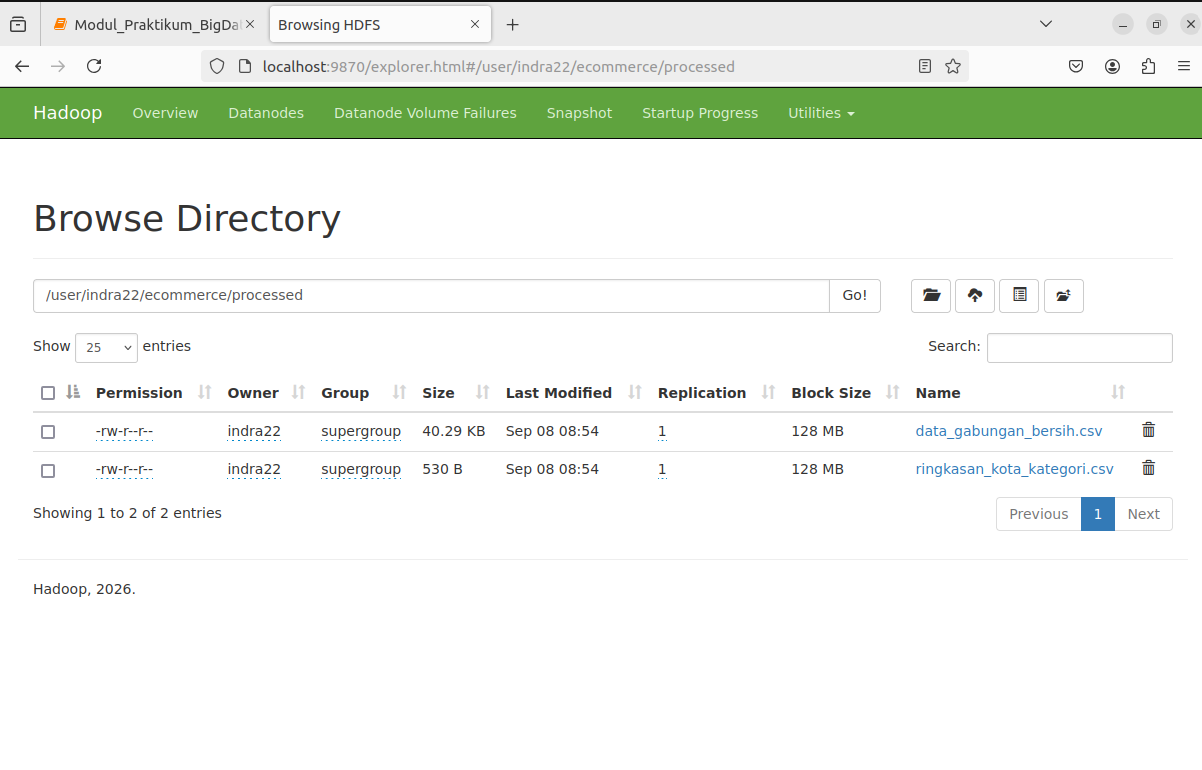

**Refleksi**

Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

Menurut saya, memisahkan data raw dan processed di HDFS membuat pengelolaan data menjadi lebih terstruktur dan mudah dipahami. Data pada folder raw dapat dianggap sebagai data asli yang belum mengalami perubahan, sehingga tetap bisa digunakan kembali jika diperlukan proses analisis yang berbeda. Sementara itu, folder processed berisi data yang sudah melalui proses penggabungan, perhitungan, atau pengolahan tertentu. Pemisahan ini juga mengurangi risiko data asli tertimpa oleh hasil pengolahan. Selain itu, struktur folder yang jelas akan memudahkan proses pencarian, pengelolaan, dan pengembangan pipeline data di tahap berikutnya. Dalam skenario Big Data, kebiasaan memisahkan data berdasarkan tahap pengolahannya akan membantu menjaga alur kerja tetap rapi dan lebih mudah dikembangkan.